In [16]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Step 2: Load dataset
jobs = pd.read_csv("linkedin_job_postings.csv")
skills = pd.read_csv("job_skills.csv")

In [18]:
# Step 3: Basic info
print(jobs.head())
print(jobs.info())

                                            job_link  \
0  https://www.linkedin.com/jobs/view/account-exe...   
1  https://www.linkedin.com/jobs/view/registered-...   
2  https://www.linkedin.com/jobs/view/restaurant-...   
3  https://www.linkedin.com/jobs/view/independent...   
4  https://www.linkedin.com/jobs/view/group-unit-...   

             last_processed_time got_summary got_ner is_being_worked  \
0   2024-01-21 07:12:29.00256+00           t       t               f   
1   2024-01-21 07:39:58.88137+00           t       t               f   
2  2024-01-21 07:40:00.251126+00           t       t               f   
3  2024-01-21 07:40:00.308133+00           t       t               f   
4  2024-01-19 09:45:09.215838+00           f       f               f   

                                           job_title  \
0  Account Executive - Dispensing (NorCal/Norther...   
1                 Registered Nurse - RN Care Manager   
2               RESTAURANT SUPERVISOR - THE FORKLIFT   
3     

In [19]:
# Step 4: Data Cleaning
jobs.drop_duplicates(inplace=True)
jobs.dropna(subset=['job_title'], inplace=True)

In [20]:
# Convert date column
jobs['last_processed_time'] = pd.to_datetime(jobs['last_processed_time'], errors='coerce')

In [21]:
# Step 5: Merge datasets
data = pd.merge(jobs, skills, on='job_link', how='left')

In [25]:

# Step 6: Clean skills column
data['job_skills'] = data['job_skills'].fillna('')
data['job_skills'] = data['job_skills'].str.lower()


In [27]:
# Step 7: Extract top skills
all_skills = ','.join(data['job_skills']).split(',')
skill_series = pd.Series(all_skills).str.strip()

top_skills = skill_series.value_counts().head(10)

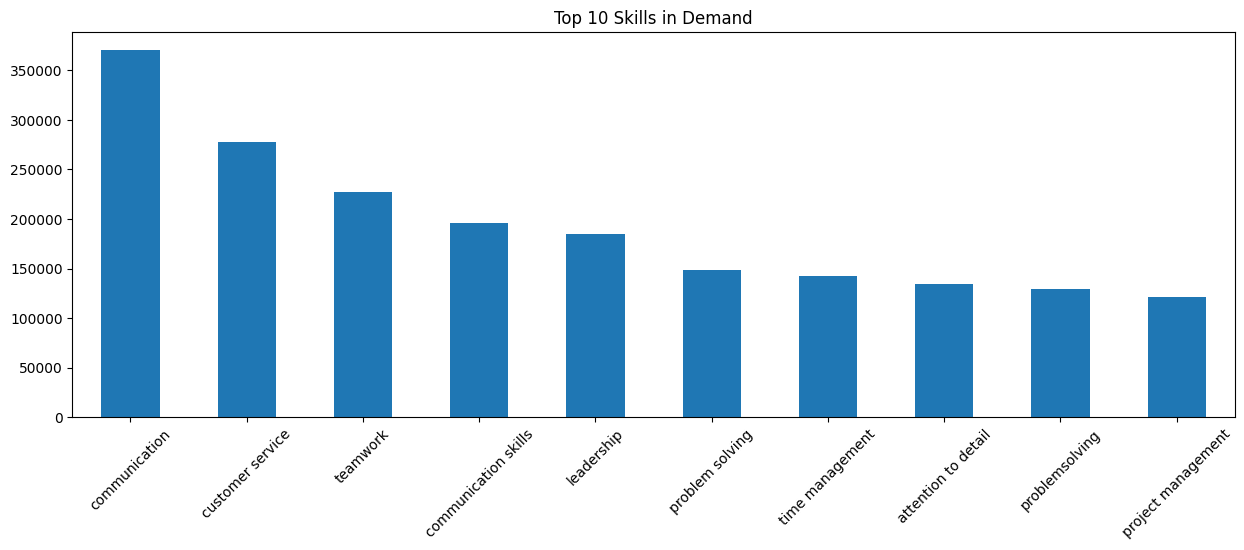

In [35]:
# Step 8: Visualization
plt.figure(figsize=(15,5))
top_skills.plot(kind='bar')
plt.title("Top 10 Skills in Demand")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Step 9: Job count by location
top_locations = data['job_location'].value_counts().head(10)


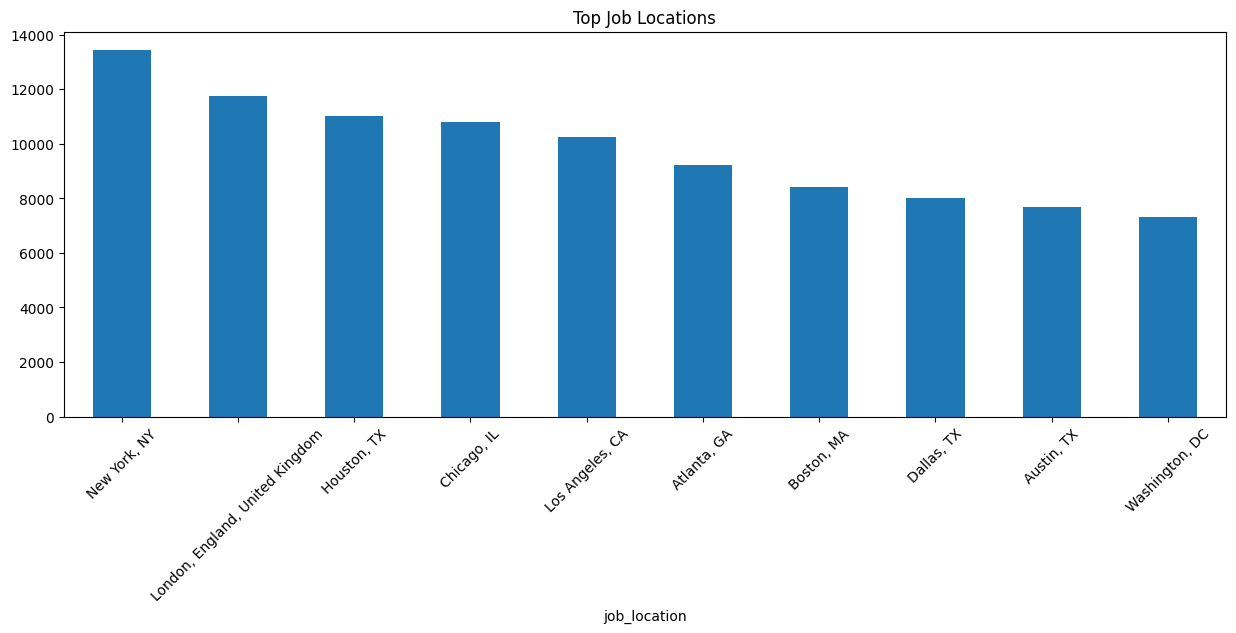

In [34]:
plt.figure(figsize=(15,5))
top_locations.plot(kind='bar')
plt.title("Top Job Locations")
plt.xticks(rotation=45)
plt.show()

In [36]:
# Step 10: Save cleaned data
data.to_csv("cleaned_jobs.csv", index=False)